In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
uploaded = files.upload()

Saving walmart-sales-dataset-of-45stores.csv to walmart-sales-dataset-of-45stores.csv


In [10]:
df = pd.read_csv("walmart-sales-dataset-of-45stores.csv")
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [11]:
# ~ Data Cleaning
# Check Missing Values
print("Missing values:\n", df.isnull().sum())

Missing values:
 Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


In [12]:
#Handle Missing Values
# Fill numerical columns with mean
for col in df.select_dtypes(include=['float64', 'int64']):
    df[col].fillna(df[col].mean(), inplace=True)

# Fill categorical columns with mode
for col in df.select_dtypes(include=['object']):
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_4311/3895920212.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mean(), inplace=True)
/tmp/ipykernel_4311/3895920212.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try usin

In [13]:
#Remove Duplicates
# Count duplicates
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

# Remove duplicates
df = df.drop_duplicates()

# Verify removal
print("Duplicates after removal:", df.duplicated().sum())

Number of duplicate rows: 0
Duplicates after removal: 0


In [16]:
#Convert Data Types
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
# Extract useful time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week

In [17]:
#Rename Columns (optional for clarity)
df.columns = df.columns.str.strip().str.replace(" ", "_")

In [18]:
#Feature Engineering
# Example: Sales per store per week
df['Sales_per_Store'] = df['Weekly_Sales'] / df['Store']

# Holiday flag conversion (if exists)
if 'Holiday_Flag' in df.columns:
    df['Holiday_Flag'] = df['Holiday_Flag'].astype('category')

In [19]:
# ~Exploratory Data Analysis (EDA)
#Total Sales
total_sales = df['Weekly_Sales'].sum()
print("Total Sales:", total_sales)

Total Sales: 6737218987.11


In [20]:
#Sales by Store
store_sales = df.groupby('Store')['Weekly_Sales'].sum().sort_values(ascending=False)
print(store_sales.head())

Store
20    3.013978e+08
4     2.995440e+08
14    2.889999e+08
13    2.865177e+08
2     2.753824e+08
Name: Weekly_Sales, dtype: float64


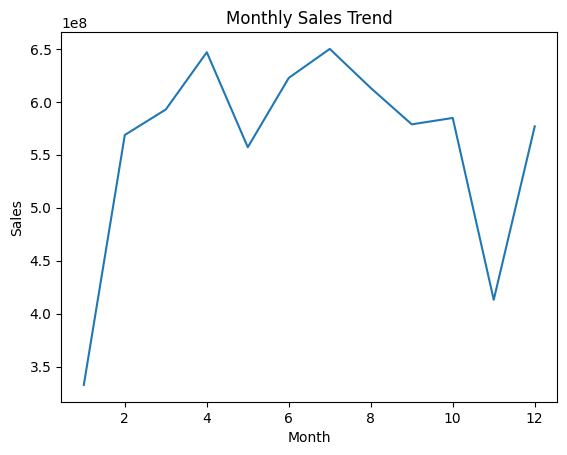

In [21]:
#Monthly Sales Trend
monthly_sales = df.groupby('Month')['Weekly_Sales'].sum()

monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

In [22]:
#Holiday vs Non-Holiday Sales
if 'Holiday_Flag' in df.columns:
    holiday_sales = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()
    print(holiday_sales)

Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64


/tmp/ipykernel_4311/1333739144.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  holiday_sales = df.groupby('Holiday_Flag')['Weekly_Sales'].mean()


                        Store  Weekly_Sales  Temperature  Fuel_Price  \
Store            1.000000e+00     -0.335332    -0.022659    0.060023   
Weekly_Sales    -3.353320e-01      1.000000    -0.063810    0.009464   
Temperature     -2.265908e-02     -0.063810     1.000000    0.144982   
Fuel_Price       6.002295e-02      0.009464     0.144982    1.000000   
CPI             -2.094919e-01     -0.072634     0.176888   -0.170642   
Unemployment     2.235313e-01     -0.106176     0.101158   -0.034684   
Year             3.474318e-12     -0.018378     0.064269    0.779470   
Month            2.910676e-15      0.076143     0.235862   -0.042156   
Week             3.106283e-15      0.074211     0.236183   -0.032403   
Sales_per_Store -5.134170e-01      0.419675     0.087362   -0.076468   

                      CPI  Unemployment          Year         Month  \
Store           -0.209492      0.223531  3.474318e-12  2.910676e-15   
Weekly_Sales    -0.072634     -0.106176 -1.837754e-02  7.614332e-

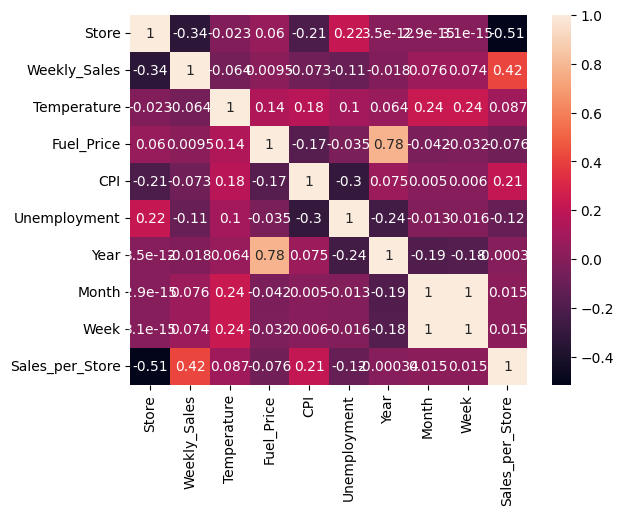

In [23]:
#Correlation Analysis
correlation = df.corr(numeric_only=True)

print(correlation)

# Heatmap
import seaborn as sns
sns.heatmap(correlation, annot=True)
plt.show()

In [24]:
#df.to_csv("cleaned_walmart_data.csv", index=False)
df.to_csv("cleaned_walmart_data.csv", index=False)

In [25]:
#Sales Prediction model
#Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

In [26]:
#Prepare Data for ML
#Select Features (X) and Target (y)
# Features (independent variables)
X = df[['Store', 'Fuel_Price', 'CPI', 'Unemployment', 'Month', 'Year']]

# Target (what we predict)
y = df['Weekly_Sales']

In [27]:
#Convert Categorical Data (if needed)
# Convert Holiday_Flag if present
if 'Holiday_Flag' in df.columns:
    X = pd.get_dummies(X.join(df['Holiday_Flag']), drop_first=True)

In [28]:
#Split Data (Train/Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [29]:
#Train Model (Linear Regression)
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [30]:
#Make Predictions
y_pred = model.predict(X_test)

In [31]:
#Evaluate Model
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

Mean Absolute Error: 431930.1341765051
R2 Score: 0.15117796098273084


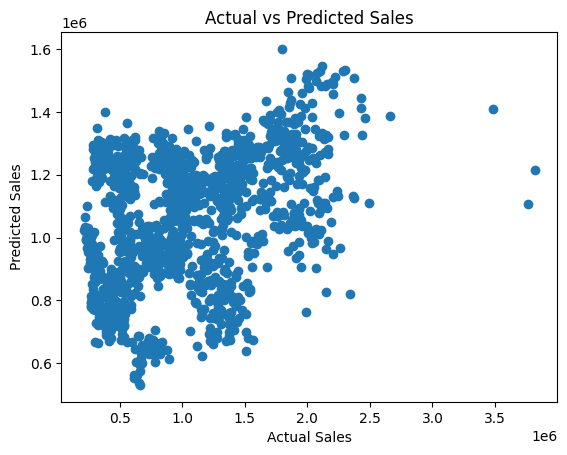

In [33]:
#Compare Actual vs Predicted
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

In [34]:
#Advanced Model (Better Accuracy)
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest R2:", r2_score(y_test, y_pred_rf))

Random Forest R2: 0.9426739756438874


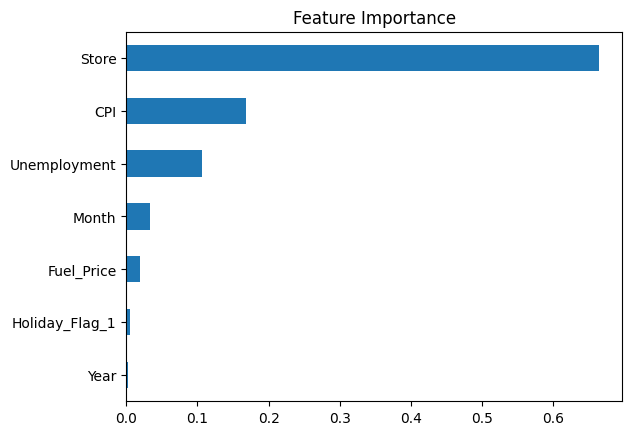

In [36]:
#Feature Importance (Very Impressive)
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()